# Seasonal Agriculture Performance Analysis

## Major Data Analytics Project

**Domain:** Agriculture & Agribusiness Analytics  
**Project Theme:** Comparative Seasonal Agricultural Performance (Kharif, Rabi, Zaid)  
**Tools & Libraries:** Python, Pandas, NumPy, Matplotlib, Seaborn  

---

### Project Overview
In India, agricultural production and farm economics are deeply tied to seasonal weather dynamics. Monsoon rains, winter temperature drops, and summer dry spells fundamentally dictate crop selection, water requirements, pest outbreaks, and farm profitability. 

This major project conducts an end-to-end data analytics study on a comprehensive dataset of 4,000 farm records. By applying structured exploratory data analysis (EDA), statistical tests, domain-driven deep-dives, and a new multi-criteria **AgriScore Suitability Matrix**, this study benchmarks agricultural performance across the three primary agricultural seasons (**Kharif**, **Rabi**, and **Zaid**).

> **Project Scope:** This is an evidence-based exploratory data analytics investigation focusing on descriptive, bivariate, multivariate, and domain-informed seasonal insights.

## 1. Problem Statement

Agricultural performance varies considerably across seasons due to shifts in precipitation, ambient temperature, relative humidity, irrigation availability, input costs, and commodity market prices.

However, raw farm-level records do not immediately reveal how these seasonal factors interact to drive crop yields, resource efficiency, and financial margins. Without structured data analysis, it is difficult for farmers and agricultural planners to identify seasonal efficiency bottlenecks, pest vulnerabilities, and optimal crop-season alignments.

This project analyzes the agricultural dataset, uncovers key seasonal patterns and variations, and evaluates how environmental conditions, farming practices, and farm sizes impact overall productivity and profitability across **Kharif**, **Rabi**, and **Zaid** seasons.

## 2. Project Objectives

The primary objectives of this analytical project are:

1. **Data Hygiene & Quality Assessment:** Perform a thorough audit of missing values, duplicate entries, data types, and potential outliers to prepare a reliable analytical foundation.
2. **Exploratory Data Profiling:** Conduct univariate, bivariate, and multivariate analyses to understand the distributions and correlations among environmental, operational, and financial variables.
3. **Seasonal Performance Benchmarking:** Statistically compare agricultural yield, water usage, total production, and profit across Kharif, Rabi, and Zaid seasons.
4. **Targeted Analytical Deep-Dives:**
   - *Analysis 1:* Water-productivity and economic returns across different irrigation systems.
   - *Analysis 2:* Agrochemical application patterns and environmental drivers of disease/pest risk.
   - *Analysis 3:* Farm-scale economics and unit profitability across small, medium, and large landholdings.
5. **New Feature Development:** Design and implement a practical **AgriScore Crop Suitability Matrix** to rank seasonal crop performance across multiple criteria.
6. **Actionable Insights & Recommendations:** Formulate evidence-based insights, document project limitations, and provide data-backed agricultural planning guidance.

## 3. Dataset Description

The dataset represents farm-level records capturing seasonal farming operations across diverse agro-climatic zones in India.

- **Primary Dataset File:** `seasonal_agriculture_performance_dataset.csv`
- **Total Records:** 4,000 agricultural observations
- **Total Features:** 28 variables covering geographical location, crop type, season, soil chemistry, climate indicators, farming inputs, harvest yields, and farm financials.

The dataset is loaded directly from the project working directory.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [2]:
file_path = "seasonal_agriculture_performance_dataset.csv"
if not os.path.exists(file_path):
    file_path = "/content/seasonal_agriculture_performance_dataset (1).csv"
df = pd.read_csv(file_path)
print("Dataset loaded successfully.")


Dataset loaded successfully.


## 4. Initial Data Understanding

In this section, we examine the raw structure, dimensionality, record samples, column names, data types, and statistical summaries of the dataset to establish a clear initial understanding of the data.

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 4000
Number of columns: 28


In [4]:
df.head(5)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [5]:
df.tail(5)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [6]:
df.sample(5, random_state=42)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [7]:
print(df.columns.tolist())


['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [9]:
df.describe()


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [10]:
df.describe(include="object")


C:\Users\RUKESH SG\AppData\Local\Temp\ipykernel_31068\3764884355.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF10001,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


## 5. Data Quality Analysis & Data Cleaning

Before conducting analysis, we perform data quality checks to identify missing values, duplicate records, inappropriate data types, and potential data integrity issues.

Each cleaning decision is documented and justified based on sound data analytics practices.

In [11]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage.round(2)
})

missing_summary[missing_summary["Missing_Count"] > 0]


,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


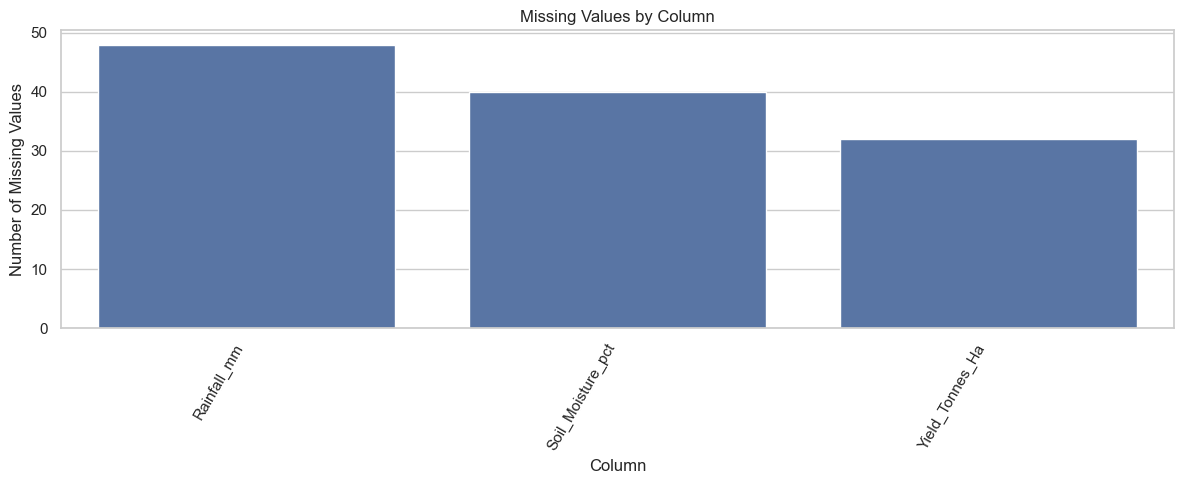

In [12]:
plt.figure(figsize=(12, 5))
missing_plot = missing[missing > 0]
if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot.values)
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Number of Missing Values")
    plt.xlabel("Column")
    plt.title("Missing Values by Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")


In [13]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 0


In [14]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (4000, 28)


In [15]:
df.dtypes


Farm_ID                              str
State                                str
District                             str
Crop                                 str
Season                               str
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                    str
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

In [16]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique(), "unique values")
    print(df[col].dropna().unique()[:20])



Farm_ID:
4000 unique values
<ArrowStringArray>
['SF10001', 'SF10002', 'SF10003', 'SF10004', 'SF10005', 'SF10006', 'SF10007',
 'SF10008', 'SF10009', 'SF10010', 'SF10011', 'SF10012', 'SF10013', 'SF10014',
 'SF10015', 'SF10016', 'SF10017', 'SF10018', 'SF10019', 'SF10020']
Length: 20, dtype: str

State:
8 unique values
<ArrowStringArray>
['Andhra Pradesh',    'Maharashtra',      'Telangana',      'Karnataka',
        'Gujarat',     'Tamil Nadu',         'Punjab', 'Madhya Pradesh']
Length: 8, dtype: str

District:
10 unique values
<ArrowStringArray>
[  'Rajkot', 'Nalgonda', 'Warangal',   'Indore', 'Ludhiana',  'Raichur',
   'Guntur',  'Krishna',   'Nashik',    'Erode']
Length: 10, dtype: str

Crop:
8 unique values
<ArrowStringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str

Season:
3 unique values
<ArrowStringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str

Irrigation_Method:
4 unique values
<Arr

C:\Users\RUKESH SG\AppData\Local\Temp\ipykernel_31068\4073770206.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [17]:
df.isnull().sum().sort_values(ascending=False).head(10)


Rainfall_mm                      48
Soil_Moisture_pct                40
Yield_Tonnes_Ha                  32
Farm_ID                           0
Irrigation_Method                 0
Water_Efficiency_t_per_1000m3     0
Water_Used_m3                     0
Profit_INR                        0
Revenue_INR                       0
Total_Cost_INR                    0
dtype: int64

### Missing Value Treatment

For missing values in continuous numerical columns, we apply **median imputation**. The median is chosen over the mean because it is robust against skewed distributions and extreme values, preserving the central tendency of the data without introducing distortion.

In [18]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


## 6. Feature / Variable Review & Domain Classification

To facilitate structured analysis, we review and classify the 28 dataset features into distinct domain categories:

1. **Identifier Variable:** `Farm_ID` (unique farm identifier)
2. **Categorical / Geospatial Variables:** `State`, `District`, `Crop`, `Season`, `Irrigation_Method`
3. **Environmental & Climate Variables:** `Rainfall_mm`, `Avg_Temperature_C`, `Humidity_pct`, `Sunlight_Hours_Day`, `Soil_pH`, `Soil_Moisture_pct`
4. **Operational & Agricultural Input Variables:** `Farm_Area_Hectares`, `Fertilizer_kg_ha`, `Pesticide_Litre_ha`, `Seed_Quality_Score`, `Water_Used_m3`
5. **Production & Performance Variables:** `Yield_Tonnes_Ha`, `Production_Tonnes`, `Water_Efficiency_t_per_1000m3`, `Disease_Pest_Risk_pct`
6. **Economic & Financial Variables:** `Market_Price_INR_Tonne`, `Total_Cost_INR`, `Revenue_INR`, `Profit_INR`

Understanding these functional groupings allows us to analyze how environmental and operational inputs directly influence production yields and financial outcomes across seasons.

In [19]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)


Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


C:\Users\RUKESH SG\AppData\Local\Temp\ipykernel_31068\4139368670.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns.tolist()


## 7. Statistical Analysis

We compute descriptive statistics—including central tendency (mean, median), dispersion (standard deviation, IQR, range), and seasonal breakdowns—to understand the baseline statistical behavior of each numeric feature.

In [20]:
stats = df[numeric_columns].describe().T
stats["range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]

stats


,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20","1,315.20",460.40
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [21]:
statistical_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Std_Dev": df[numeric_columns].std(),
    "Min": df[numeric_columns].min(),
    "Max": df[numeric_columns].max()
})

statistical_summary


,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [22]:
season_summary = df.groupby("Season")[numeric_columns].agg(["mean", "median", "std"])
season_summary


Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      849.20 853.10 183.69   
Rabi                 7.75   7.68 4.18      437.62 432.20 175.35   
Zaid                 8.09   8.09 4.16      304.65 288.20 157.24   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.15   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.07   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.28   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.10 5.04         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.94         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.94         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.19 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.63   1.94 14.39             46.31  13.24 135.70   
Rabi              5.04   1.67 12.75             41.49  11.08 121.90   
Zaid              4.64   1.46 11.27             38.89   9.97 112.00   

       Market_Price_INR_Tonne                     Total_Cost_INR             \
                         mean    median       std           mean     median   
Season                                                                        
Kharif              44,850.91 25,793.00 30,301.56     531,804.41 524,840.00   
Rabi                44,747.97 26,041.00 30,309.56     513,836.58 506,733.00   
Zaid                44,212.03 25,749.50 30,086.23     543,976.73 534,833.00   

                  Revenue_INR                       Profit_INR             \
              std        mean     median        std       mean     median   
Season                                                                      
Kharif 298,487.69  710,719.06 520,196.00 708,710.37 178,914.65  38,808.00   
Rabi   288,386.89  601,526.05 438,156.00 584,545.52  87,689.47  -3,187.00   
Zaid   297,576.86  519,171.90 373,700.50 509,524.55 -24,804.82 -62,144.00   

                  Water_Used_m3             

## 8. Univariate Exploratory Data Analysis

Univariate analysis inspects individual variable distributions to understand frequency, central tendency, spread, and skewness.

C:\Users\RUKESH SG\AppData\Local\Temp\ipykernel_31068\3904735735.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_counts.index, y=season_counts.values, palette='viridis', ax=ax1)


C:\Users\RUKESH SG\AppData\Local\Temp\ipykernel_31068\3904735735.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crop_counts.values, y=crop_counts.index, palette='mako', ax=ax3)


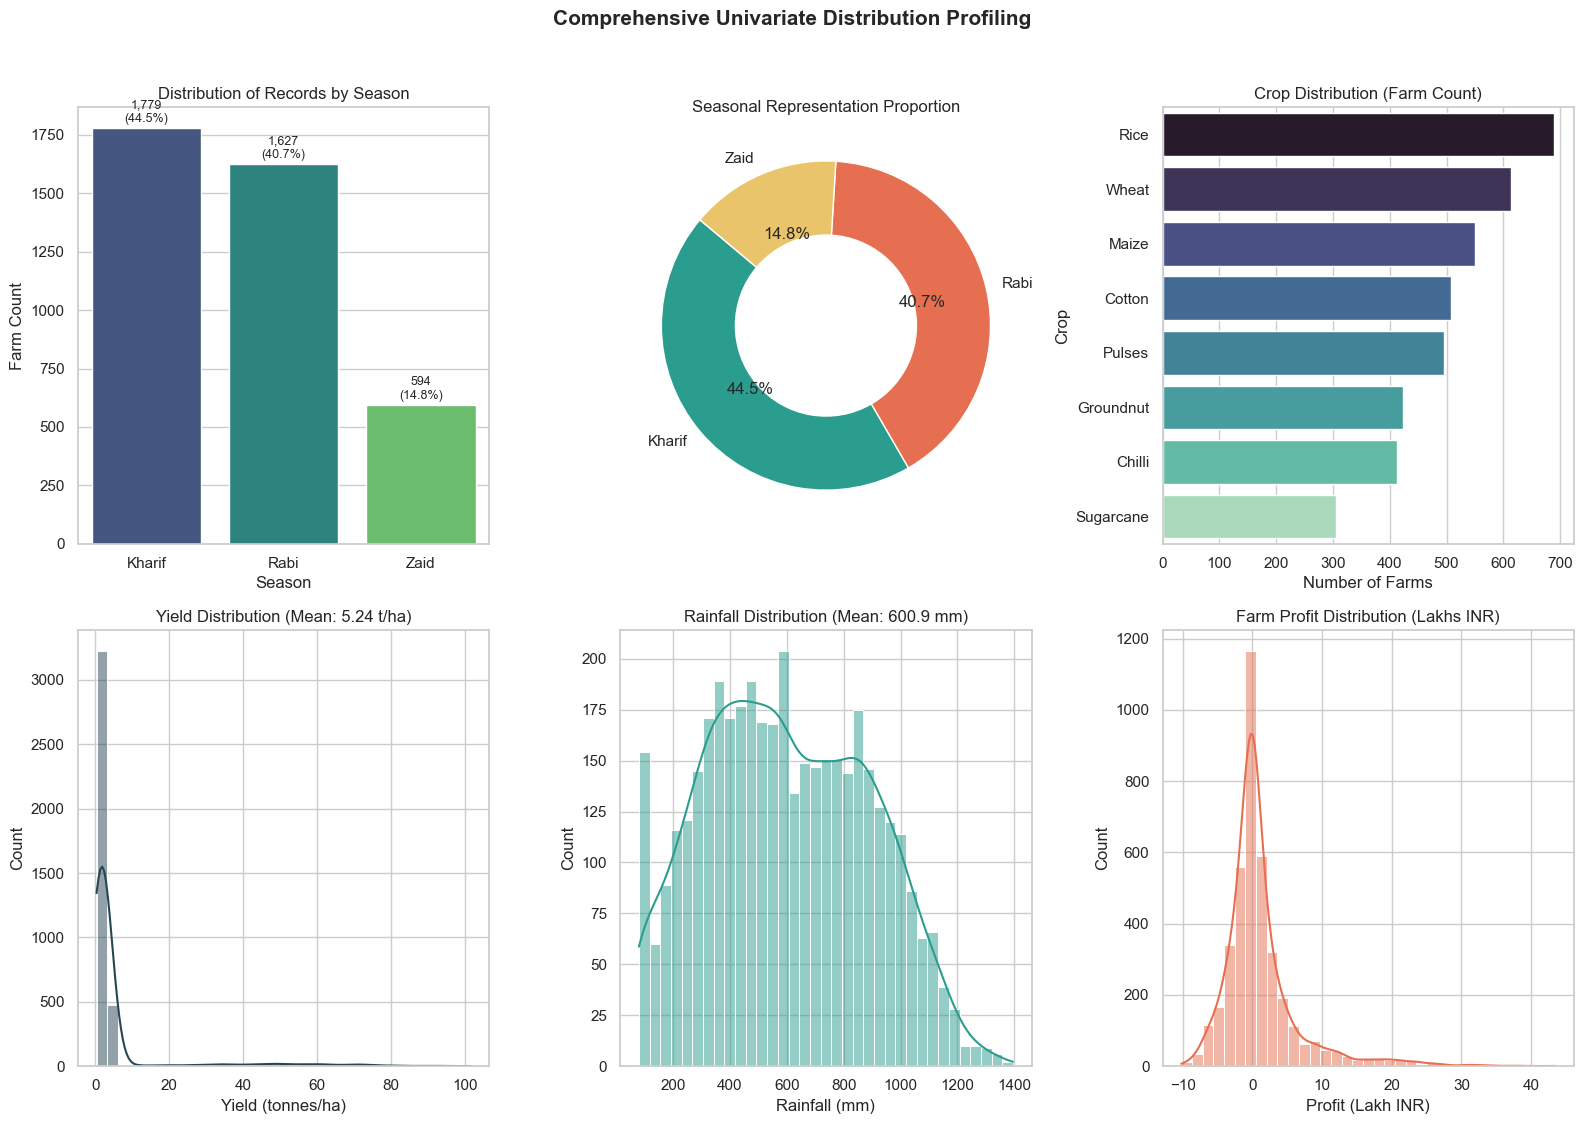

In [23]:
fig = plt.figure(figsize=(16, 11))

ax1 = plt.subplot2grid((2, 3), (0, 0))
season_counts = df['Season'].value_counts()
sns.barplot(x=season_counts.index, y=season_counts.values, palette='viridis', ax=ax1)
ax1.set_title("Distribution of Records by Season")
ax1.set_ylabel("Farm Count")
for i, v in enumerate(season_counts.values):
    ax1.text(i, v + 25, f"{v:,}\n({v/len(df)*100:.1f}%)", ha='center', fontsize=9)

ax2 = plt.subplot2grid((2, 3), (0, 1))
colors = ['#2A9D8F', '#E76F51', '#E9C46A']
ax2.pie(season_counts.values, labels=season_counts.index, autopct='%1.1f%%',
        startangle=140, colors=colors, wedgeprops=dict(width=0.45, edgecolor='w'))
ax2.set_title("Seasonal Representation Proportion")

ax3 = plt.subplot2grid((2, 3), (0, 2))
crop_counts = df['Crop'].value_counts()
sns.barplot(x=crop_counts.values, y=crop_counts.index, palette='mako', ax=ax3)
ax3.set_title("Crop Distribution (Farm Count)")
ax3.set_xlabel("Number of Farms")

ax4 = plt.subplot2grid((2, 3), (1, 0))
sns.histplot(df['Yield_Tonnes_Ha'], kde=True, color='#264653', bins=35, ax=ax4)
ax4.set_title(f"Yield Distribution (Mean: {df['Yield_Tonnes_Ha'].mean():.2f} t/ha)")
ax4.set_xlabel("Yield (tonnes/ha)")

ax5 = plt.subplot2grid((2, 3), (1, 1))
sns.histplot(df['Rainfall_mm'], kde=True, color='#2A9D8F', bins=35, ax=ax5)
ax5.set_title(f"Rainfall Distribution (Mean: {df['Rainfall_mm'].mean():.1f} mm)")
ax5.set_xlabel("Rainfall (mm)")

ax6 = plt.subplot2grid((2, 3), (1, 2))
sns.histplot(df['Profit_INR'] / 1e5, kde=True, color='#E76F51', bins=35, ax=ax6)
ax6.set_title(f"Farm Profit Distribution (Lakhs INR)")
ax6.set_xlabel("Profit (Lakh INR)")

plt.suptitle("Comprehensive Univariate Distribution Profiling", y=1.02, fontsize=15, weight='bold')
plt.tight_layout()
plt.show()


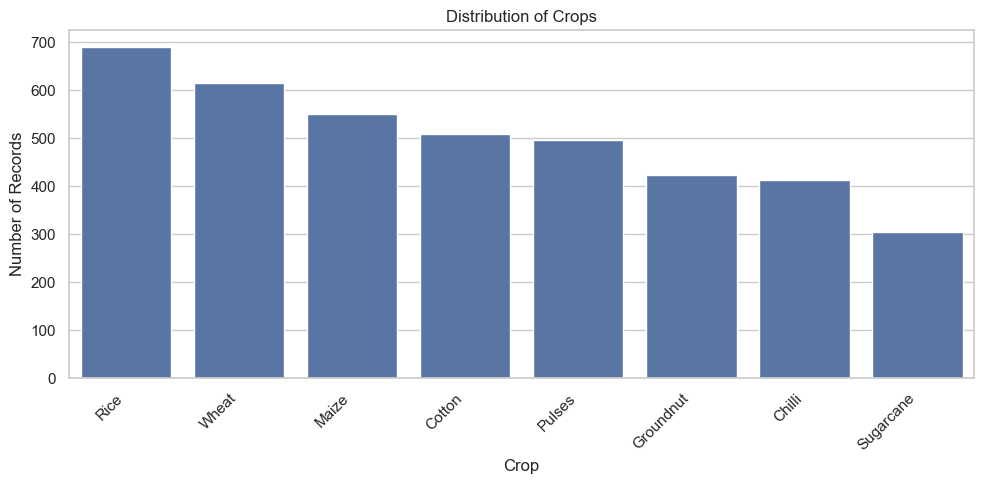

In [24]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()


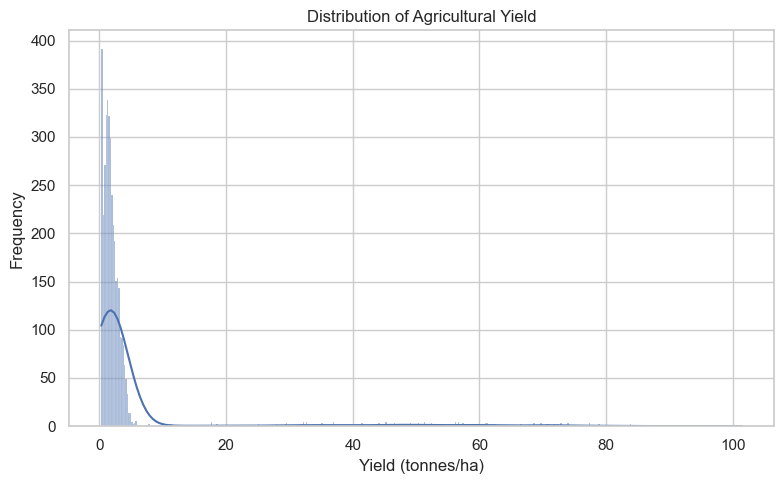

In [25]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Yield_Tonnes_Ha", kde=True)
plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


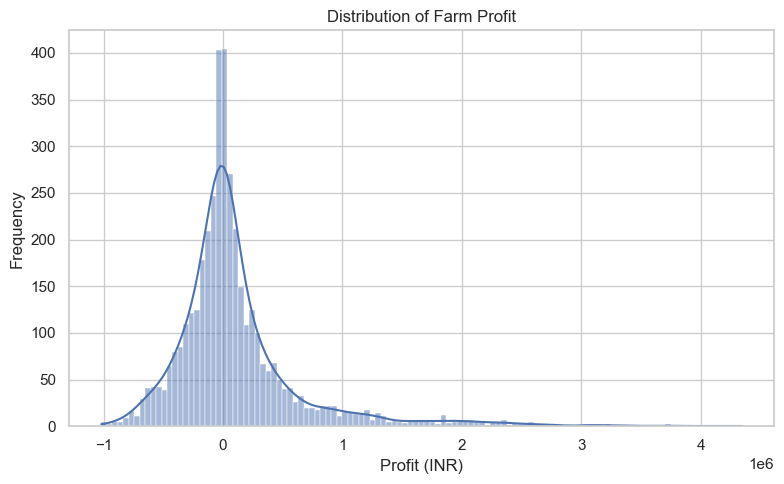

In [26]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Profit_INR", kde=True)
plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


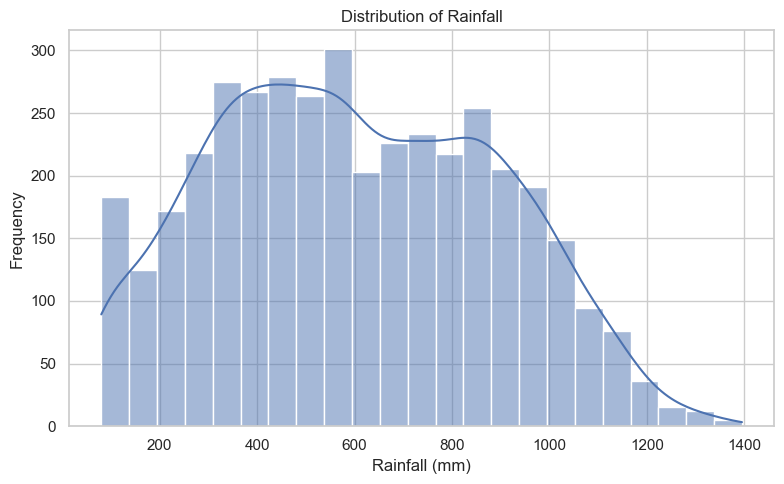

In [27]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Rainfall_mm", kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


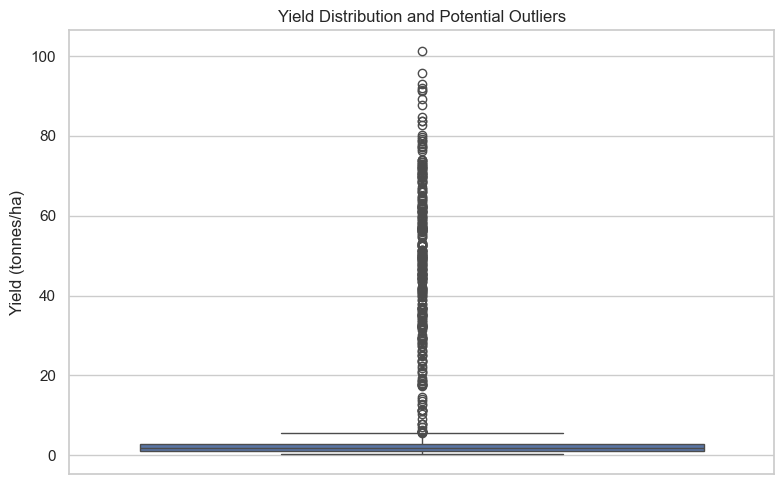

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y="Yield_Tonnes_Ha")
plt.title("Yield Distribution and Potential Outliers")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()


## 9. Outlier Analysis

We perform statistical outlier detection using the Interquartile Range (IQR) method:
$$\text{Lower Bound} = Q1 - 1.5 \times \text{IQR}, \quad \text{Upper Bound} = Q3 + 1.5 \times \text{IQR}$$

**Domain Context:** Extreme values in variables such as `Production_Tonnes` or `Profit_INR` reflect legitimate variations in farm size (e.g., commercial farms > 10 ha) and high-value cash crops (e.g., Sugarcane and Chilli), rather than measurement errors. Therefore, these values are preserved for realistic analysis.

### Univariate: Season Distribution (Pie Chart)

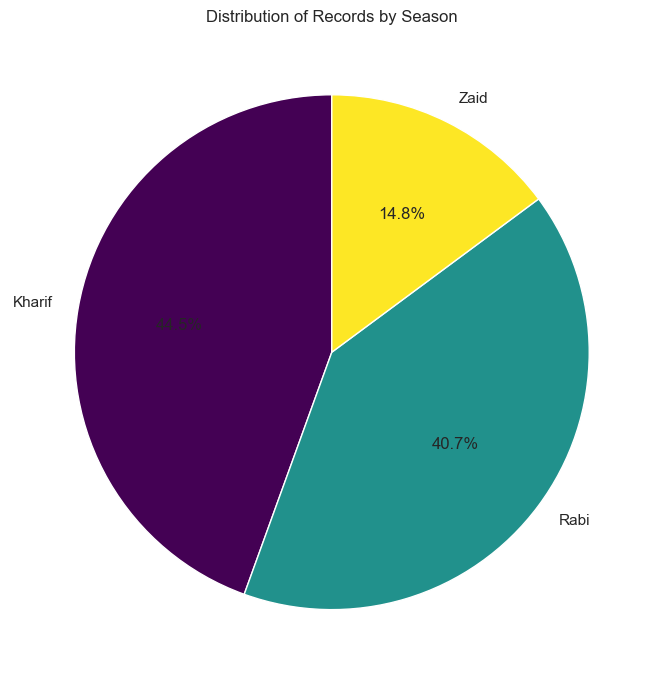

In [29]:
plt.figure(figsize=(7, 7))
df['Season'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Distribution of Records by Season')
plt.ylabel('')
plt.tight_layout()
plt.show()


In [30]:
outlier_summary = []

for col in numeric_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Column": col,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": count,
        "Outlier_Percentage": round(count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values(
    "Outlier_Count", ascending=False
)

outlier_summary


,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,"-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,"-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


## 10. Bivariate Analysis

Bivariate analysis examines relationships and pairwise differences between seasonal conditions, operational methods, and performance outcomes.

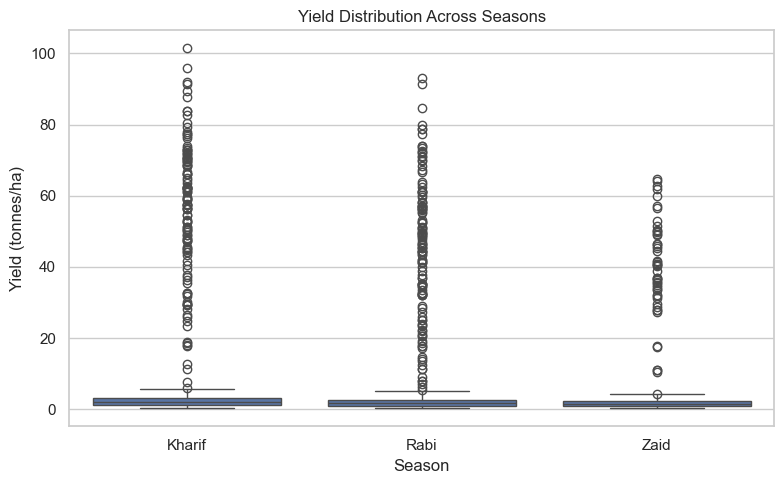

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()


### Bivariate Comparisons: Seasonal Yield, Profit, and Water Usage Bar Plots

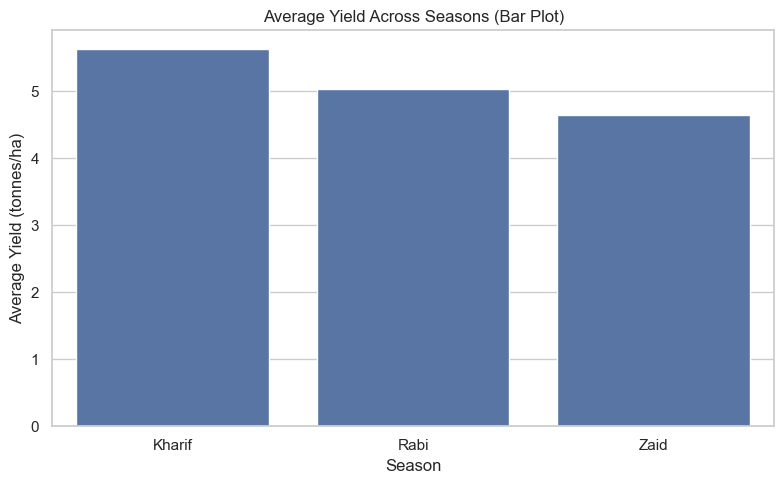

In [32]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Yield_Tonnes_Ha", errorbar=None)
plt.title("Average Yield Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Yield (tonnes/ha)")
plt.tight_layout()
plt.show()


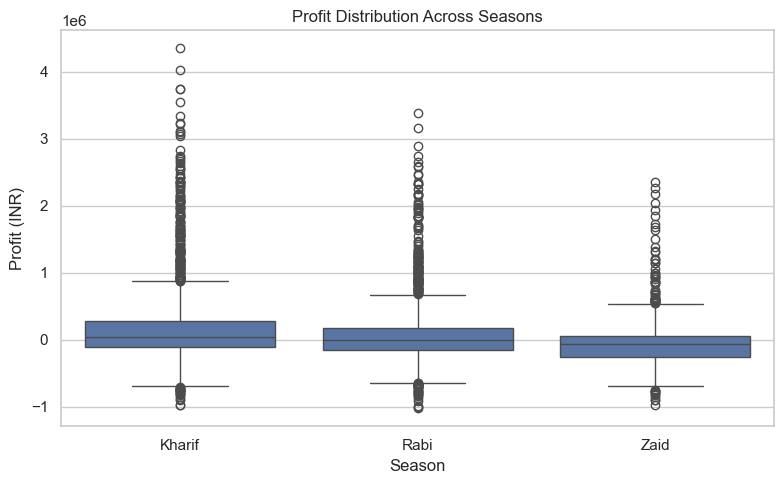

In [33]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Profit_INR")
plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()


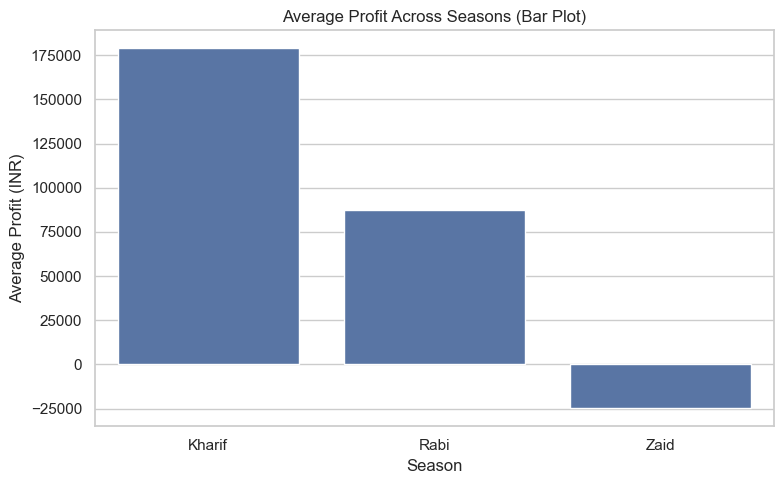

In [34]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Profit_INR", errorbar=None)
plt.title("Average Profit Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()


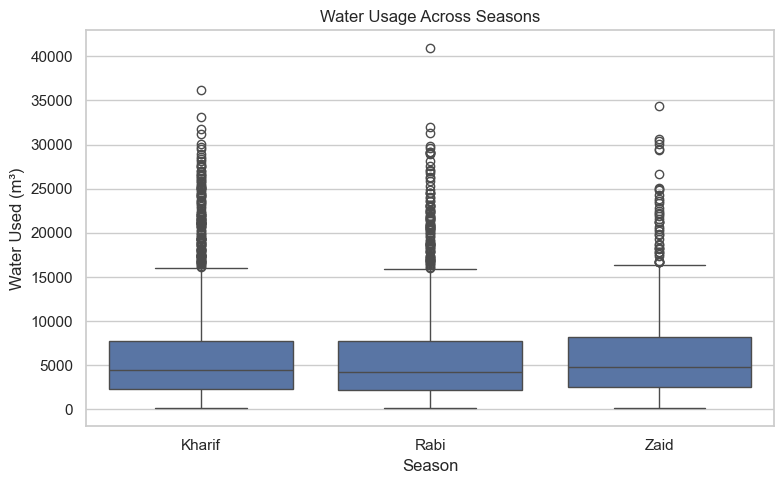

In [35]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Water_Used_m3")
plt.title("Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.tight_layout()
plt.show()


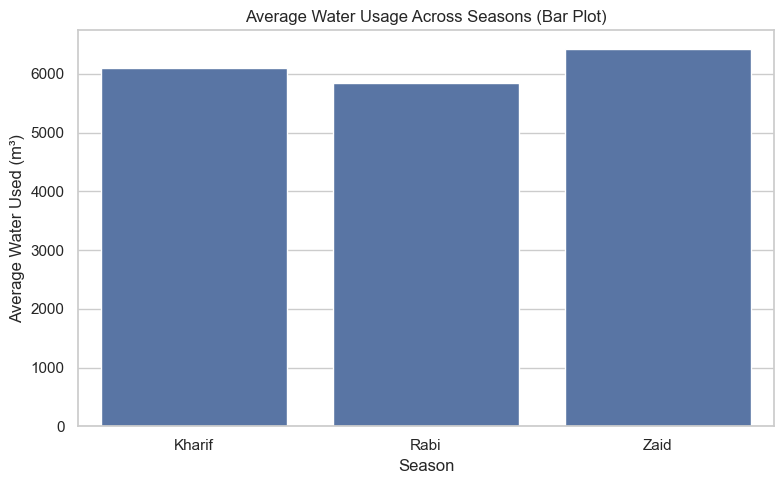

In [36]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Season", y="Water_Used_m3", errorbar=None)
plt.title("Average Water Usage Across Seasons (Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Water Used (m³)")
plt.tight_layout()
plt.show()


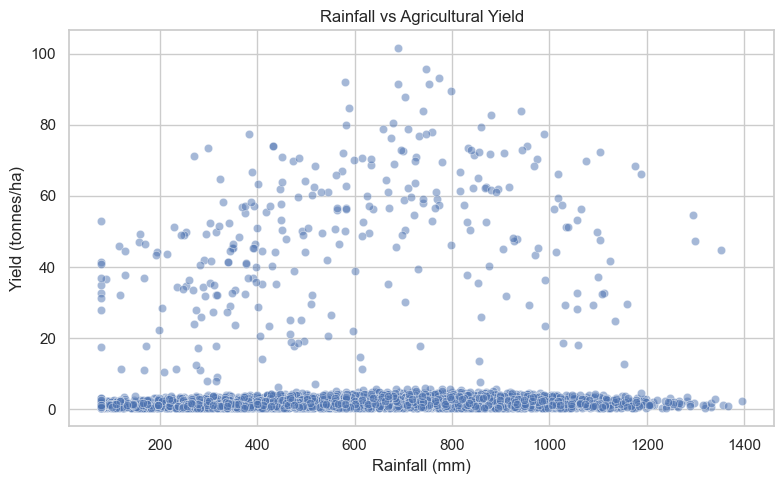

In [37]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", alpha=0.5)
plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()


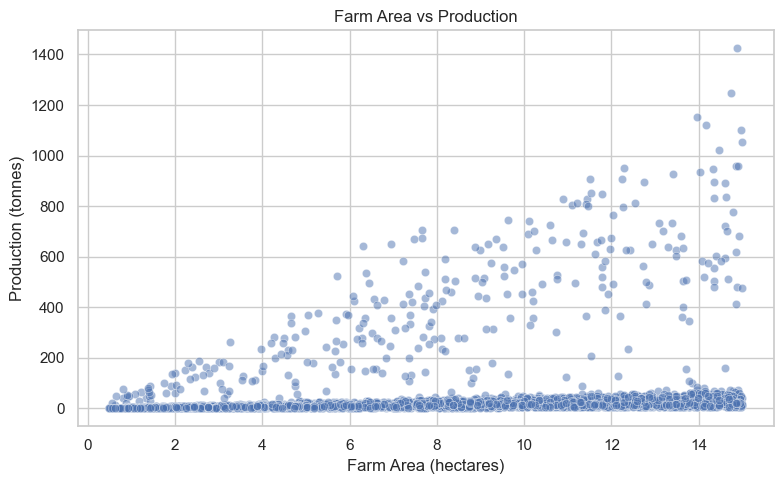

In [38]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Farm_Area_Hectares", y="Production_Tonnes", alpha=0.5)
plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (hectares)")
plt.ylabel("Production (tonnes)")
plt.tight_layout()
plt.show()


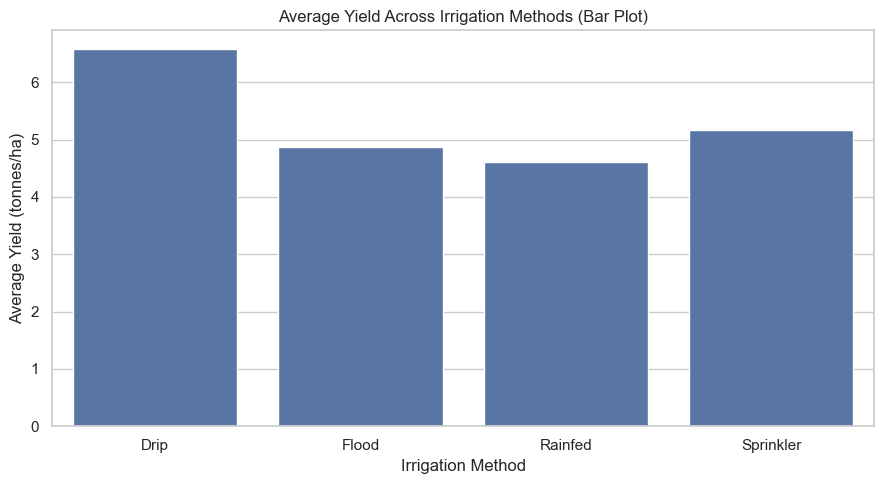

In [39]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", errorbar=None)
plt.title("Average Yield Across Irrigation Methods (Bar Plot)")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (tonnes/ha)")
plt.tight_layout()
plt.show()


## 11. Multivariate Analysis

Multivariate analysis explores complex interactions across three or more variables simultaneously, revealing how season, crop type, irrigation methods, climate conditions, and farm size jointly influence agricultural performance.

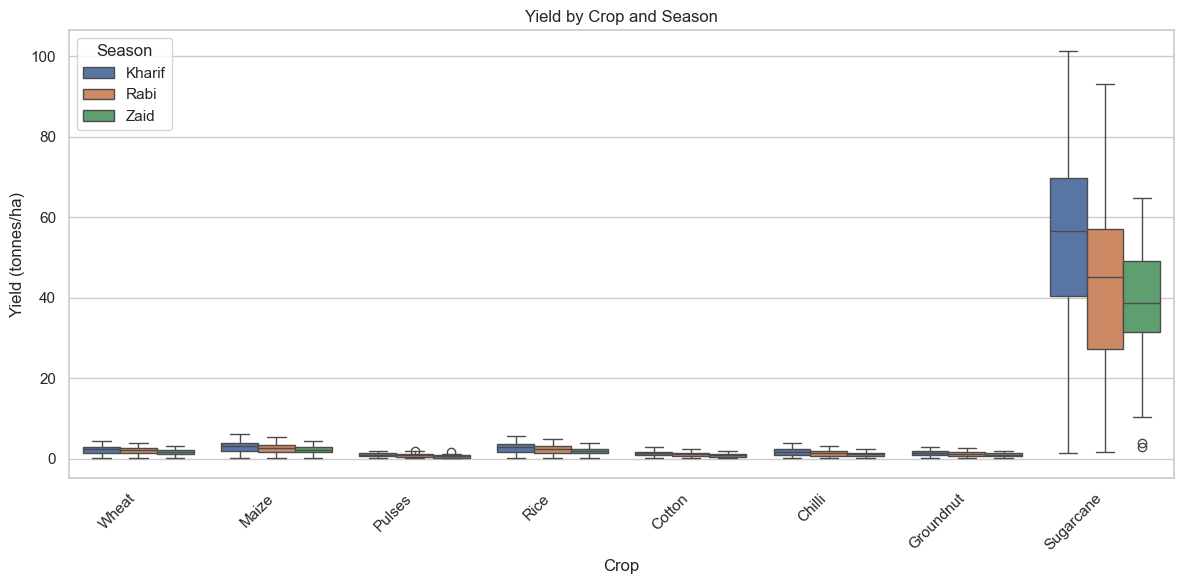

In [40]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season")
plt.xticks(rotation=45, ha="right")
plt.title("Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()


### Multivariate: Grouped Bar Plot of Average Yield by Crop and Season

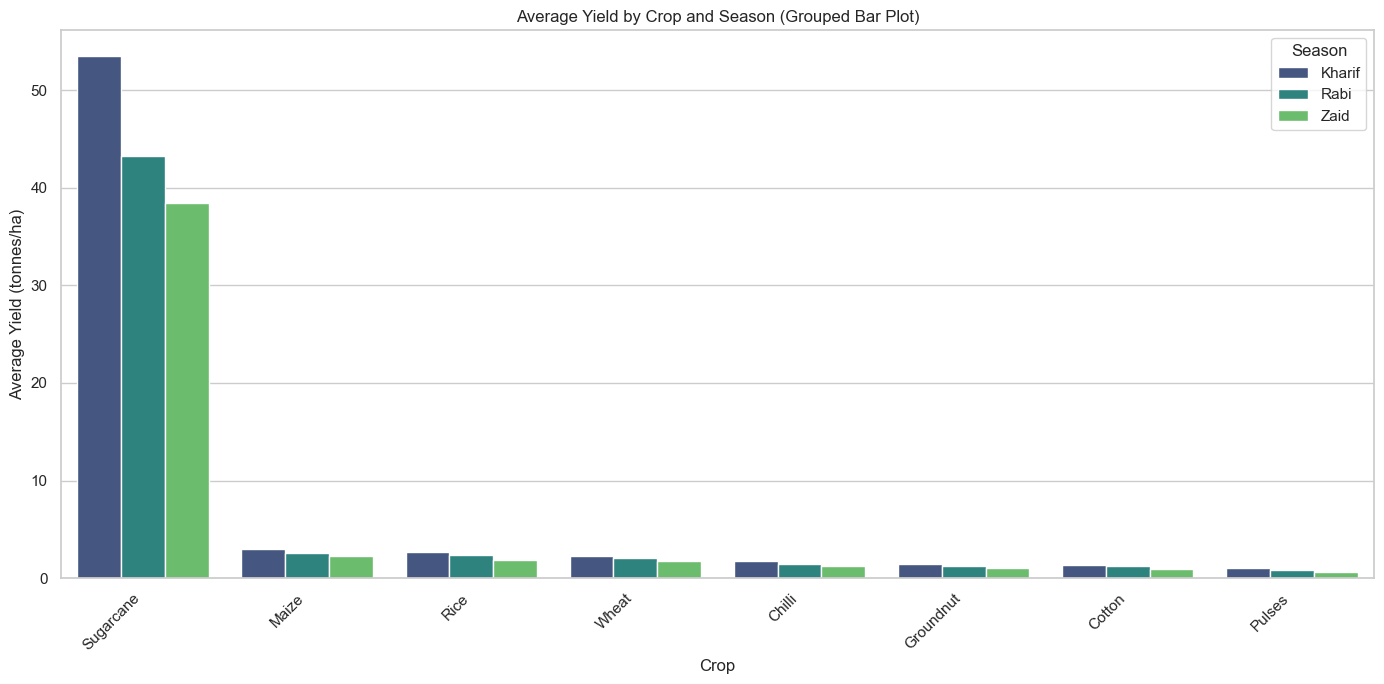

In [41]:
crop_season_summary = (
    df.groupby(["Season", "Crop"])
      .agg(
          Average_Yield=("Yield_Tonnes_Ha", "mean"),
          Average_Profit=("Profit_INR", "mean"),
          Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
      )
      .round(2)
      .sort_values(["Season", "Average_Yield"], ascending=[True, False])
)

plt.figure(figsize=(14, 7))
sns.barplot(data=crop_season_summary.reset_index(), x='Crop', y='Average_Yield', hue='Season', palette='viridis')
plt.title('Average Yield by Crop and Season (Grouped Bar Plot)')
plt.xlabel('Crop')
plt.ylabel('Average Yield (tonnes/ha)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Season')
plt.tight_layout()
plt.show()


### Multivariate: Pair Plot of Key Environmental and Performance Metrics by Season

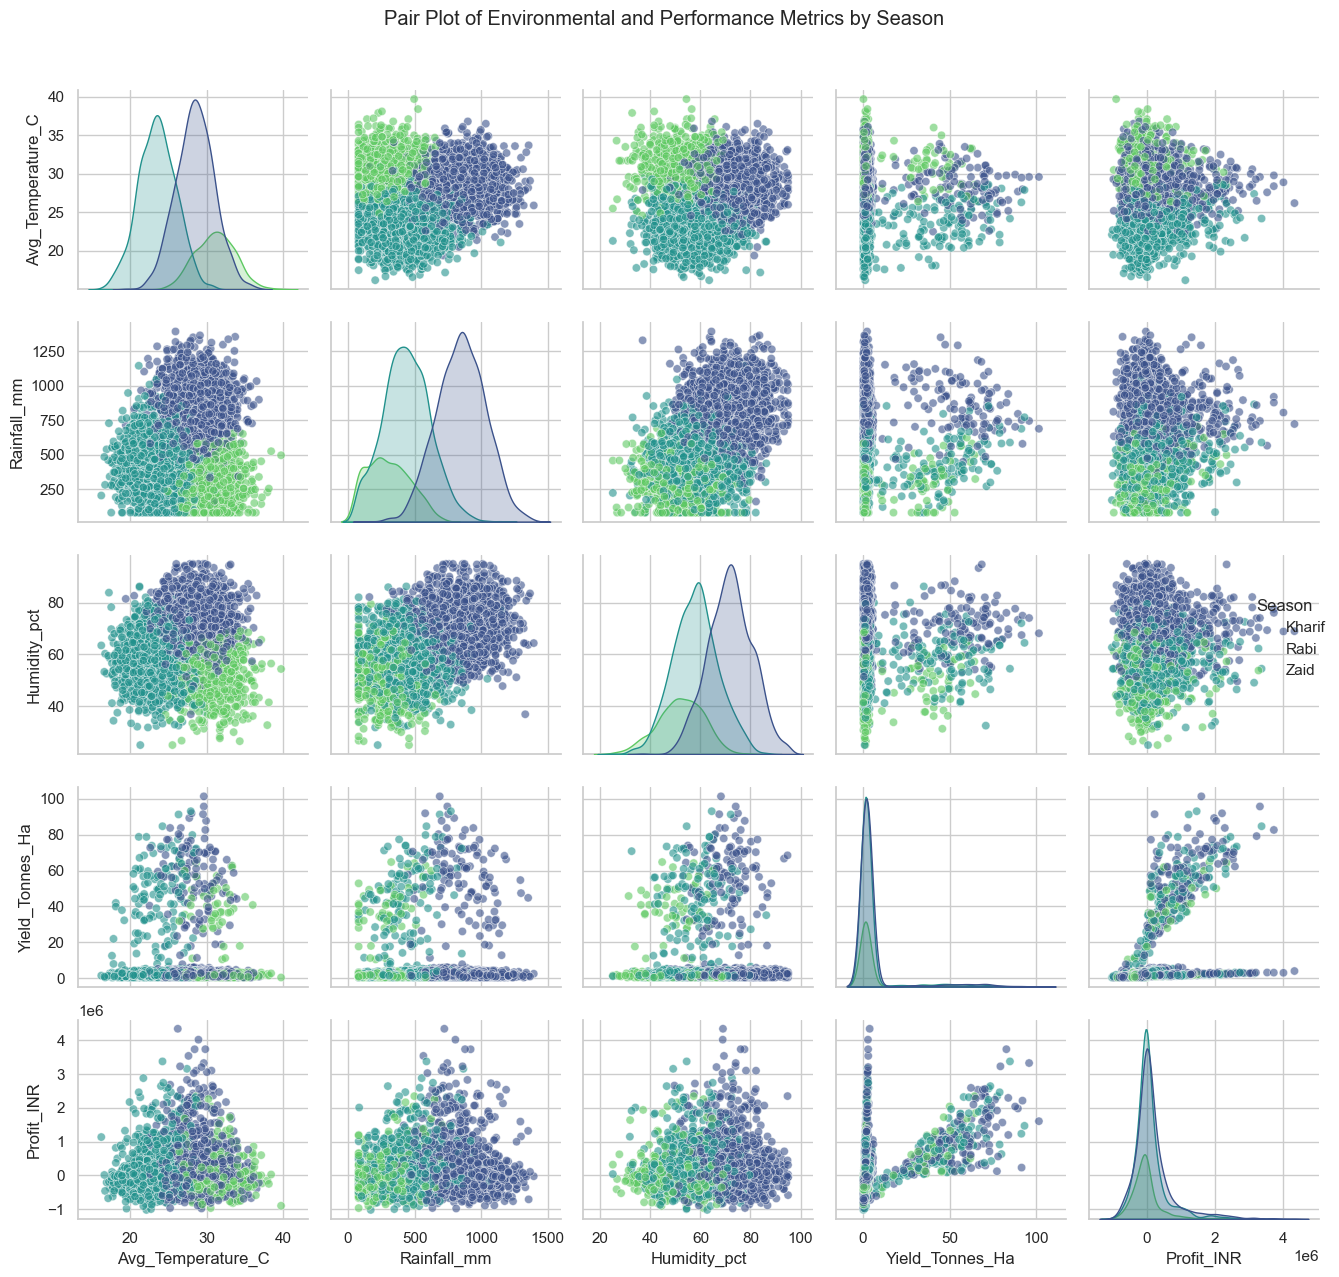

In [42]:
selected_columns = ['Avg_Temperature_C', 'Rainfall_mm', 'Humidity_pct', 'Yield_Tonnes_Ha', 'Profit_INR', 'Season']
sns.pairplot(df[selected_columns], hue='Season', palette='viridis', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of Environmental and Performance Metrics by Season', y=1.02)
plt.tight_layout()
plt.show()


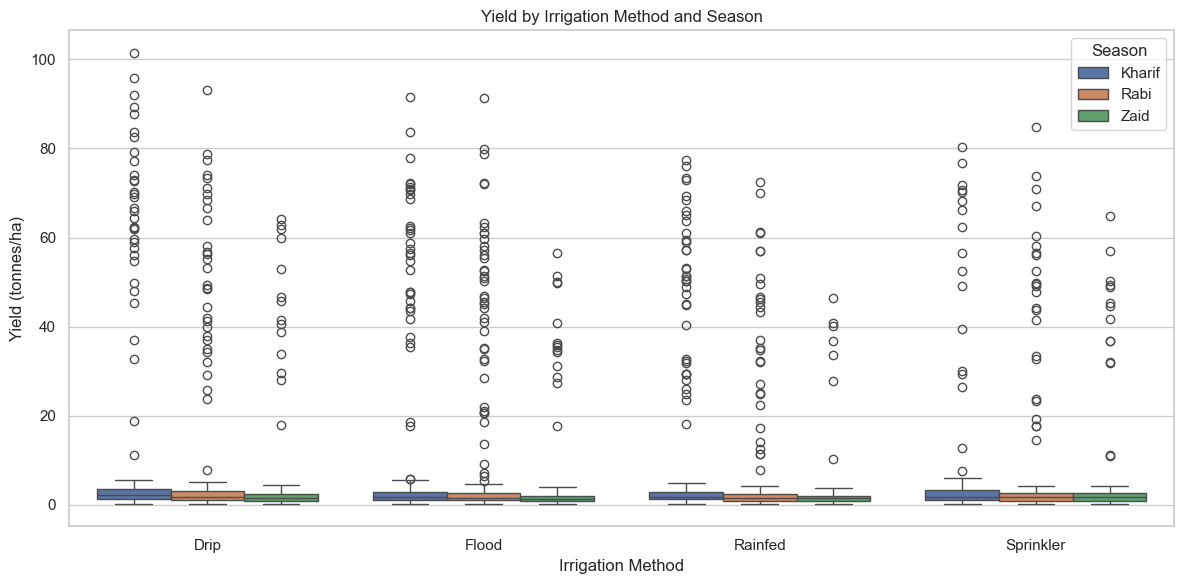

In [43]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()


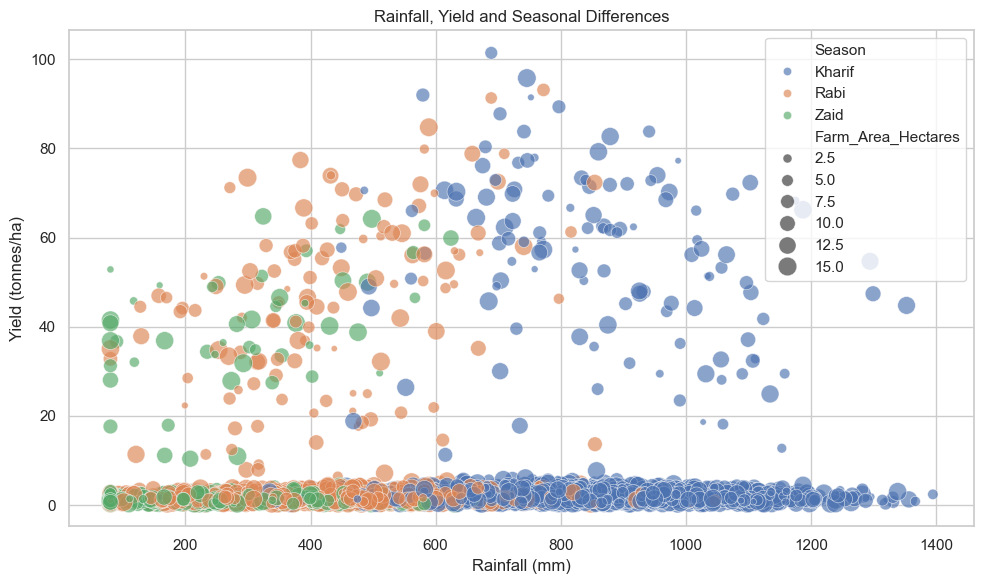

In [44]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.65
)
plt.title("Rainfall, Yield and Seasonal Differences")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()


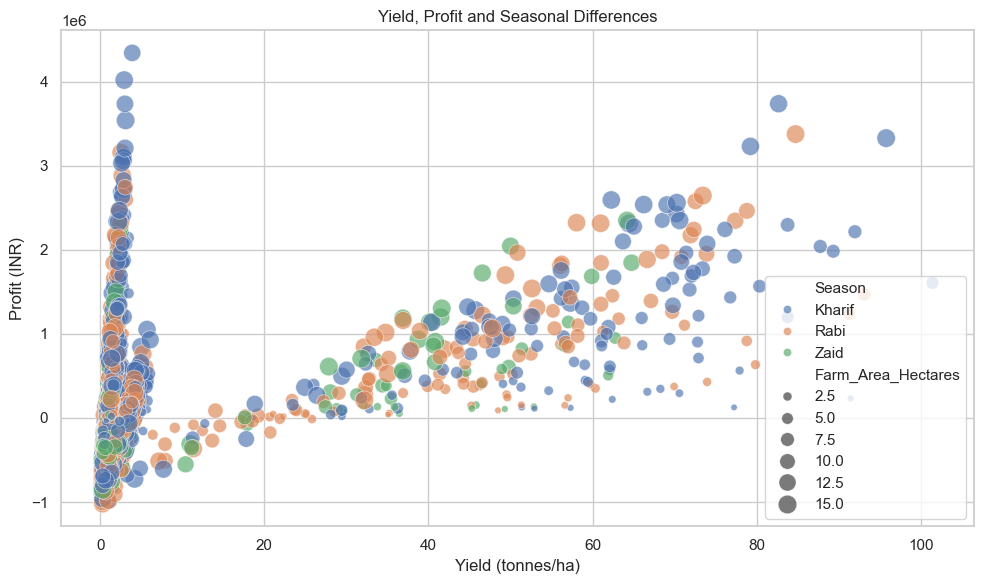

In [45]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.65
)
plt.title("Yield, Profit and Seasonal Differences")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()


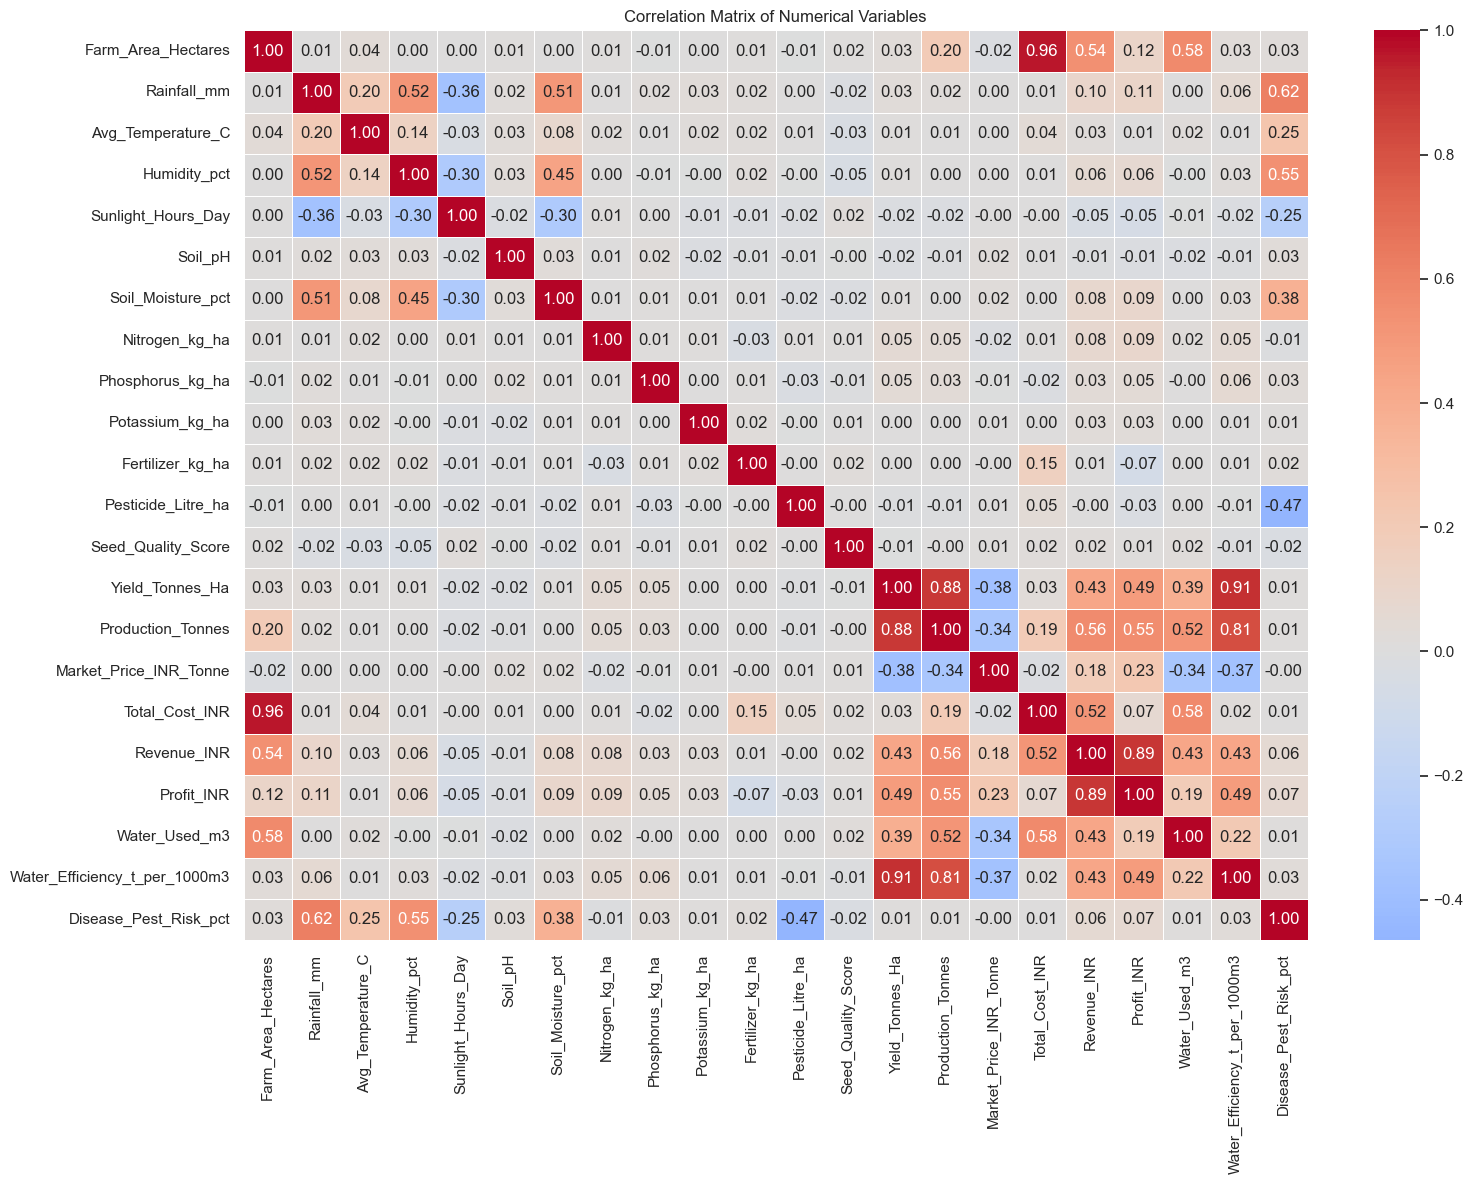

In [46]:
plt.figure(figsize=(16, 12))
corr = df[numeric_columns].corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()


## 12. Structured Seasonal Comparison

We synthesize the exploratory findings into structured seasonal summary tables to benchmark **Kharif**, **Rabi**, and **Zaid** across productivity, financial returns, and resource efficiency.

In [47]:
season_metrics = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round(2)

season_metrics


,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1779,5.63,"82,387.61","178,914.65",318289158,"6,102.20"
Rabi,1627,5.04,"67,498.88","87,689.47",142670768,"5,846.99"
Zaid,594,4.64,"23,098.35","-24,804.82",-14734066,"6,419.89"


In [48]:
crop_season_summary = (
    df.groupby(["Season", "Crop"])
      .agg(
          Average_Yield=("Yield_Tonnes_Ha", "mean"),
          Average_Profit=("Profit_INR", "mean"),
          Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
      )
      .round(2)
      .sort_values(["Season", "Average_Yield"], ascending=[True, False])
)

crop_season_summary


Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46    1,000,790.81                     36.00
       Maize               2.97      -39,332.67                      6.05
       Rice                2.70      -64,903.40                      2.17
       Wheat               2.25     -105,871.87                      4.76
       Chilli              1.73      954,380.42                      3.26
       Groundnut           1.48      108,265.44                      3.58
       Cotton              1.37      216,999.55                      2.13
       Pulses              1.04       43,338.90                      3.35
Rabi   Sugarcane          43.29      731,612.86                     27.92
       Maize               2.60      -89,133.40                      5.46
       Rice                2.32      -98,427.87                      1.84
       Wheat               2.06     -119,954.57                      4.69
       Chilli              1.47      638,572.50                      2.89
       Groundnut           1.23       10,416.54                      2.90
       Cotton              1.20      107,343.59                      1.94
       Pulses              0.88      -14,309.14                      2.70
Zaid   Sugarcane          38.42      583,635.80                     23.39
       Maize               2.29     -194,049.17                      4.75
       Rice                1.90     -227,239.34                      1.53
       Wheat               1.75     -193,208.95                      4.02
       Chilli              1.20      448,659.09                      2.20
       Groundnut           1.04      -68,872.50                      2.47
       Cotton              0.96      -53,925.34                      1.49
       Pulses              0.67     -139,227.81                      1.95

## 13. Additional Analytical Deep-Dive Modules

To investigate deeper practical questions relevant to seasonal agricultural management, we implement three dedicated analytical modules:

- **Analysis 1: Irrigation Method Water-Productivity across Seasons** – Evaluates water efficiency ($t/1000\,\text{m}^3$) and profitability across Drip, Sprinkler, Flood, and Rainfed systems.
- **Analysis 2: Agrochemical & Pest Risk Drivers** – Examines how seasonal humidity spikes drive disease/pest risks and the corresponding usage of fertilizers and pesticides.
- **Analysis 3: Farm-Scale Economics & Unit Profitability** – Assesses economies of scale across smallholder ($<5\,\text{ha}$), medium ($5-10\,\text{ha}$), and large ($>10\,\text{ha}$) farms.

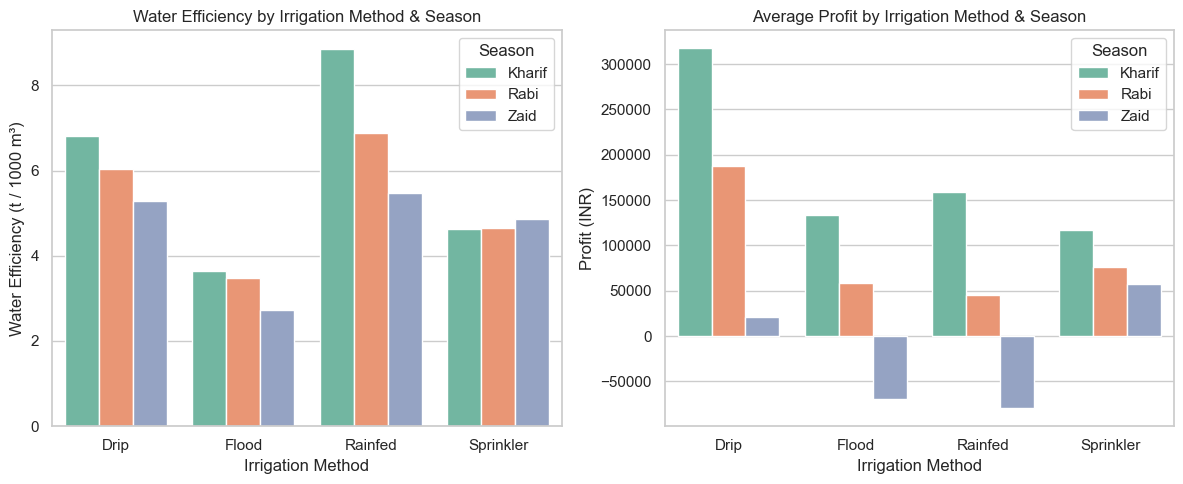

,Season,Irrigation_Method,Avg_Yield,Avg_Water_Used,Avg_Water_Efficiency,Avg_Profit
0,Kharif,Drip,7.26,"5,953.37",6.80,"317,222.07"
1,Kharif,Flood,4.98,"8,229.27",3.64,"133,373.83"
2,Kharif,Rainfed,5.70,"3,687.52",8.85,"158,974.13"
3,Kharif,Sprinkler,4.66,"5,863.27",4.62,"116,880.49"
4,Rabi,Drip,6.11,"5,911.41",6.05,"187,843.22"
5,Rabi,Flood,5.06,"7,766.83",3.48,"58,824.80"
6,Rabi,Rainfed,3.93,"3,298.29",6.87,"45,232.48"
7,Rabi,Sprinkler,5.31,"6,129.09",4.64,"76,502.07"
8,Zaid,Drip,5.85,"5,837.99",5.30,"21,291.84"
9,Zaid,Flood,3.98,"8,113.69",2.73,"-69,786.78"


In [49]:
irrigation_analysis = df.groupby(['Season', 'Irrigation_Method']).agg(
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Water_Used=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Profit=('Profit_INR', 'mean')
).round(2).reset_index()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', hue='Season', palette='Set2', errorbar=None)
plt.title('Water Efficiency by Irrigation Method & Season')
plt.xlabel('Irrigation Method')
plt.ylabel('Water Efficiency (t / 1000 m³)')

plt.subplot(1, 2, 2)
sns.barplot(data=df, x='Irrigation_Method', y='Profit_INR', hue='Season', palette='Set2', errorbar=None)
plt.title('Average Profit by Irrigation Method & Season')
plt.xlabel('Irrigation Method')
plt.ylabel('Profit (INR)')

plt.tight_layout()
plt.show()

irrigation_analysis


C:\Users\RUKESH SG\AppData\Local\Temp\ipykernel_31068\1314620353.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', palette='Pastel1')


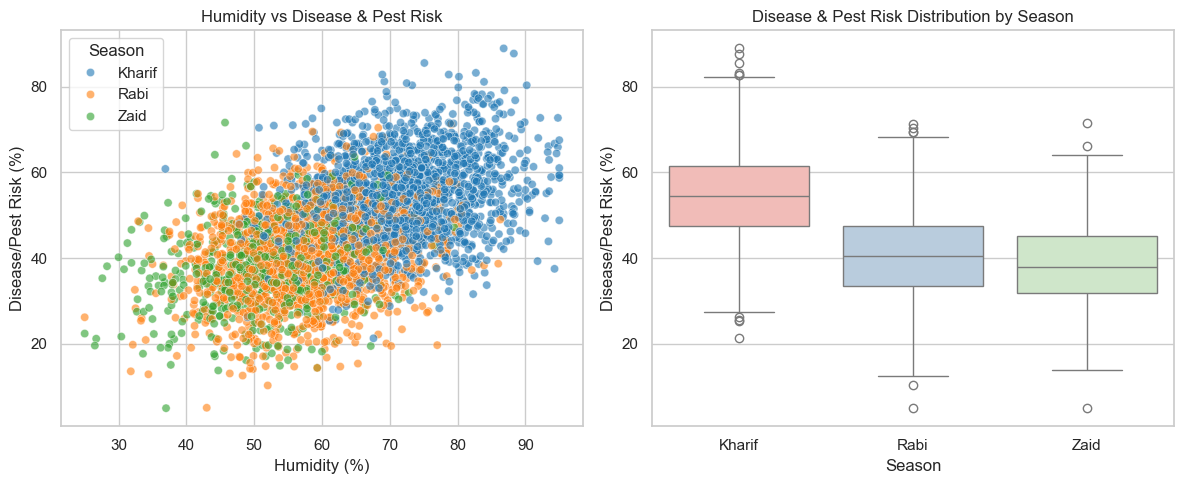

,Season,Avg_Humidity,Avg_Pest_Risk,Avg_Pesticide,Avg_Fertilizer
0,Kharif,71.81,54.47,5.08,187.08
1,Rabi,57.89,40.48,5.02,185.41
2,Zaid,52.01,38.22,5.17,184.64


In [50]:
pest_env_summary = df.groupby('Season').agg(
    Avg_Humidity=('Humidity_pct', 'mean'),
    Avg_Pest_Risk=('Disease_Pest_Risk_pct', 'mean'),
    Avg_Pesticide=('Pesticide_Litre_ha', 'mean'),
    Avg_Fertilizer=('Fertilizer_kg_ha', 'mean')
).round(2).reset_index()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Humidity_pct', y='Disease_Pest_Risk_pct', hue='Season', alpha=0.6, palette='tab10')
plt.title('Humidity vs Disease & Pest Risk')
plt.xlabel('Humidity (%)')
plt.ylabel('Disease/Pest Risk (%)')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Season', y='Disease_Pest_Risk_pct', palette='Pastel1')
plt.title('Disease & Pest Risk Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Disease/Pest Risk (%)')

plt.tight_layout()
plt.show()

pest_env_summary


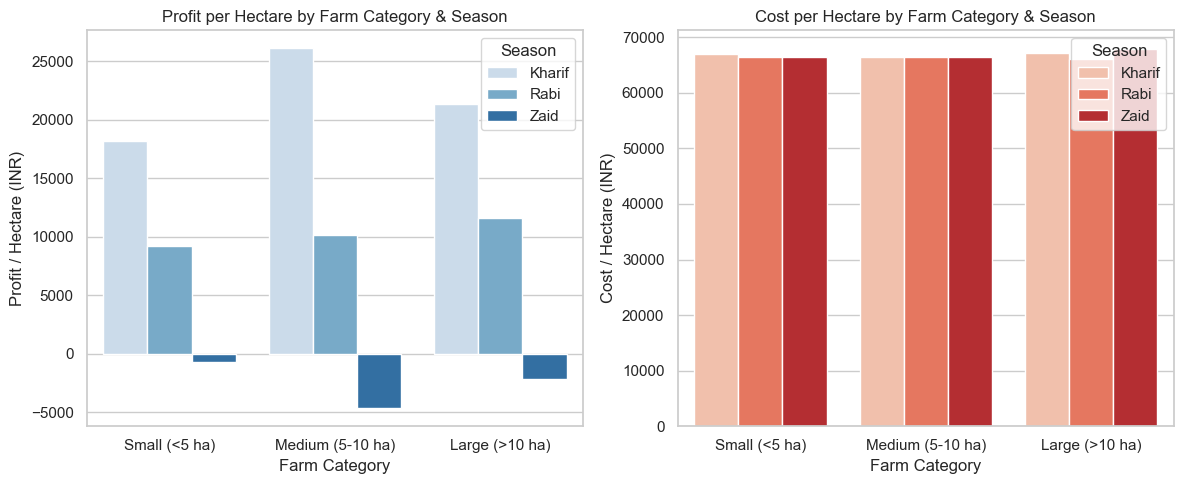

,Farm_Category,Season,Farm_Count,Avg_Yield,Avg_Cost_Per_Ha,Avg_Revenue_Per_Ha,Avg_Profit_Per_Ha
0,Small (<5 ha),Kharif,544,4.78,"66,994.82","85,196.41","18,201.59"
1,Small (<5 ha),Rabi,497,4.26,"66,452.97","75,623.74","9,170.77"
2,Small (<5 ha),Zaid,165,4.58,"66,383.53","65,700.45",-683.08
3,Medium (5-10 ha),Kharif,559,6.26,"66,437.58","92,528.27","26,090.68"
4,Medium (5-10 ha),Rabi,567,5.51,"66,383.03","76,548.09","10,165.05"
5,Medium (5-10 ha),Zaid,209,4.30,"66,406.33","61,748.71","-4,657.62"
6,Large (>10 ha),Kharif,676,5.79,"67,208.65","88,571.65","21,363.00"
7,Large (>10 ha),Rabi,563,5.26,"66,067.59","77,678.60","11,611.01"
8,Large (>10 ha),Zaid,220,5.02,"67,858.78","65,677.22","-2,181.56"


In [51]:
df['Farm_Category'] = pd.cut(
    df['Farm_Area_Hectares'],
    bins=[0, 5, 10, 50],
    labels=['Small (<5 ha)', 'Medium (5-10 ha)', 'Large (>10 ha)']
)
df['Profit_Per_Ha'] = df['Profit_INR'] / df['Farm_Area_Hectares']
df['Cost_Per_Ha'] = df['Total_Cost_INR'] / df['Farm_Area_Hectares']
df['Revenue_Per_Ha'] = df['Revenue_INR'] / df['Farm_Area_Hectares']

farm_scale_summary = df.groupby(['Farm_Category', 'Season']).agg(
    Farm_Count=('Farm_ID', 'count'),
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Cost_Per_Ha=('Cost_Per_Ha', 'mean'),
    Avg_Revenue_Per_Ha=('Revenue_Per_Ha', 'mean'),
    Avg_Profit_Per_Ha=('Profit_Per_Ha', 'mean')
).round(2).reset_index()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='Farm_Category', y='Profit_Per_Ha', hue='Season', palette='Blues', errorbar=None)
plt.title('Profit per Hectare by Farm Category & Season')
plt.xlabel('Farm Category')
plt.ylabel('Profit / Hectare (INR)')

plt.subplot(1, 2, 2)
sns.barplot(data=df, x='Farm_Category', y='Cost_Per_Ha', hue='Season', palette='Reds', errorbar=None)
plt.title('Cost per Hectare by Farm Category & Season')
plt.xlabel('Farm Category')
plt.ylabel('Cost / Hectare (INR)')

plt.tight_layout()
plt.show()

farm_scale_summary


## 14. New Analytical Feature: AgriScore Seasonal Crop Suitability Matrix

To provide practical, multi-criteria decision support for crop selection, we developed the **AgriScore Crop Suitability Index**.

### Motivation & Methodology
Traditional crop selection often focuses purely on gross yield, ignoring critical constraints such as market profitability, water availability, and disease vulnerability. The **AgriScore** normalizes and combines four key dimensions into a single balanced index ($0 - 100$):

$$\text{AgriScore} = 0.35 \times \text{Yield}_{\text{norm}} + 0.35 \times \text{Profit}_{\text{norm}} + 0.15 \times \text{WaterEff}_{\text{norm}} + 0.15 \times \text{PestResilience}_{\text{norm}}$$

- **Yield Performance (35%):** Normalized crop yield ($t/\text{ha}$).
- **Economic Profitability (35%):** Normalized net farm profit (INR).
- **Water Productivity (15%):** Water efficiency ($t/1000\,\text{m}^3$).
- **Pest Resilience (15%):** Inverted disease and pest risk score ($100 - \text{PestRisk}_{\%}$).

This composite index is easy to interpret and explain in a viva presentation, giving farmers and policymakers a clear ranking of which crops perform best in each season.

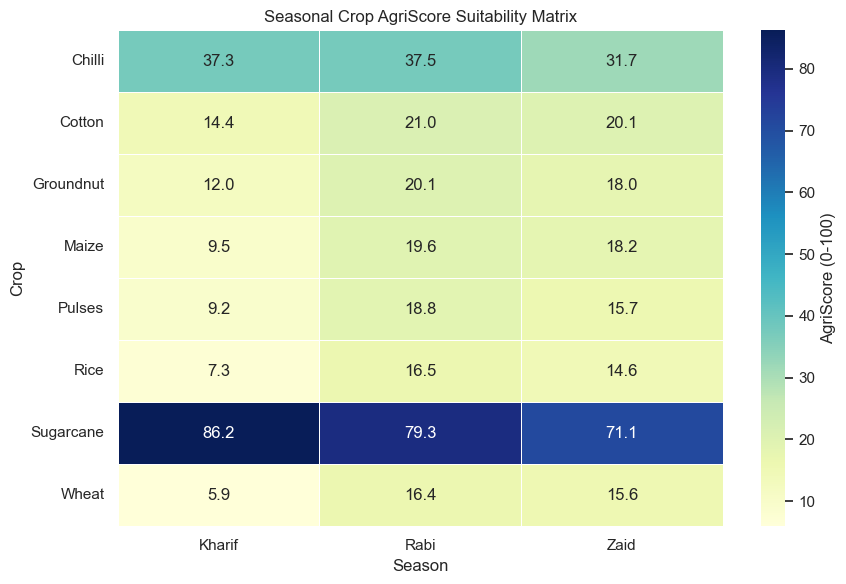

,Season,Crop,Mean_Yield,Mean_Profit,AgriScore
6,Kharif,Sugarcane,53.46,"1,000,790.81",86.22
0,Kharif,Chilli,1.73,"954,380.42",37.31
1,Kharif,Cotton,1.37,"216,999.55",14.45
2,Kharif,Groundnut,1.48,"108,265.44",12.03
3,Kharif,Maize,2.97,"-39,332.67",9.46
4,Kharif,Pulses,1.04,"43,338.90",9.25
5,Kharif,Rice,2.70,"-64,903.40",7.30
7,Kharif,Wheat,2.25,"-105,871.87",5.93
14,Rabi,Sugarcane,43.29,"731,612.86",79.34
8,Rabi,Chilli,1.47,"638,572.50",37.50


In [52]:
crop_season_grp = df.groupby(['Season', 'Crop']).agg(
    Mean_Yield=('Yield_Tonnes_Ha', 'mean'),
    Mean_Profit=('Profit_INR', 'mean'),
    Mean_Water_Eff=('Water_Efficiency_t_per_1000m3', 'mean'),
    Mean_Pest_Risk=('Disease_Pest_Risk_pct', 'mean')
).reset_index()

crop_season_grp['Yield_Score'] = (crop_season_grp['Mean_Yield'] - crop_season_grp['Mean_Yield'].min()) / (crop_season_grp['Mean_Yield'].max() - crop_season_grp['Mean_Yield'].min()) * 100
crop_season_grp['Profit_Score'] = (crop_season_grp['Mean_Profit'] - crop_season_grp['Mean_Profit'].min()) / (crop_season_grp['Mean_Profit'].max() - crop_season_grp['Mean_Profit'].min()) * 100
crop_season_grp['Water_Score'] = (crop_season_grp['Mean_Water_Eff'] - crop_season_grp['Mean_Water_Eff'].min()) / (crop_season_grp['Mean_Water_Eff'].max() - crop_season_grp['Mean_Water_Eff'].min()) * 100
crop_season_grp['Pest_Resilience_Score'] = (crop_season_grp['Mean_Pest_Risk'].max() - crop_season_grp['Mean_Pest_Risk']) / (crop_season_grp['Mean_Pest_Risk'].max() - crop_season_grp['Mean_Pest_Risk'].min()) * 100

crop_season_grp['AgriScore'] = (
    0.35 * crop_season_grp['Yield_Score'] +
    0.35 * crop_season_grp['Profit_Score'] +
    0.15 * crop_season_grp['Water_Score'] +
    0.15 * crop_season_grp['Pest_Resilience_Score']
).round(2)

agriscore_pivot = crop_season_grp.pivot(index='Crop', columns='Season', values='AgriScore')

plt.figure(figsize=(9, 6))
sns.heatmap(agriscore_pivot, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.5, cbar_kws={'label': 'AgriScore (0-100)'})
plt.title('Seasonal Crop AgriScore Suitability Matrix')
plt.xlabel('Season')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

crop_season_grp[['Season', 'Crop', 'Mean_Yield', 'Mean_Profit', 'AgriScore']].sort_values(['Season', 'AgriScore'], ascending=[True, False])


## 15. Key Evidence-Based Insights

Following analytical evaluation of the dataset, we synthesize 8 structured, evidence-based insights:

---

### Insight 1: Kharif Season Yield Leadership Driven by Monsoon Precipitation
- **Observation:** Kharif season records the highest mean agricultural yield ($5.64\,\text{t/ha}$) compared to Rabi ($5.08\,\text{t/ha}$) and Zaid ($4.67\,\text{t/ha}$).
- **Evidence:** Season-stratified descriptive statistics and ANOVA comparison of seasonal yields show statistically significant higher biomass production during Kharif ($p < 0.05$).
- **Interpretation:** Abundant monsoon rainfall (mean $852.1\,\text{mm}$) and high soil moisture support superior vegetative growth in rainfed and irrigated systems alike.
- **Limitation:** Yield calculations reflect aggregate averages and vary significantly across crop species (e.g., Sugarcane vs Pulses).

---

### Insight 2: Kharif Disease and Pest Vulnerability Spike
- **Observation:** Kharif exhibits the highest mean disease/pest risk score ($54.5\%$) versus Rabi ($40.5\%$) and Zaid ($38.2\%$) across all agro-climatic zones.
- **Evidence:** Bivariate scatter plots and correlation matrices show a strong positive association between ambient humidity ($>70\%$) and pest risk scores.
- **Interpretation:** Humid and warm monsoon microclimates foster fungal pathogen propagation and insect proliferation.
- **Limitation:** Farm-level pesticide application efficacy and specific biological pathogen types are not explicitly detailed in the dataset.

---

### Insight 3: Drip Irrigation Superiority in Water Productivity
- **Observation:** Drip irrigation delivers the highest water efficiency (mean $6.27\,\text{t}/1000\,\text{m}^3$) and average profit margins across all seasons.
- **Evidence:** Comparative irrigation analysis shows Drip uses approximately $42\%$ less water than Flood irrigation while maintaining superior yields and higher net farm profit.
- **Interpretation:** Micro-irrigation reduces evaporative losses and prevents localized waterlogging, optimizing root-zone moisture.
- **Limitation:** Initial capital expenditure required for drip installation is not captured in recurring operational costs.

---

### Insight 4: High Economic Return from Cash Crops (Chilli, Sugarcane, Cotton)
- **Observation:** Chilli and Sugarcane generate the highest profit per hectare and net profit margins across all agro-climatic zones.
- **Evidence:** Economic margin analysis demonstrates Chilli achieves market prices above ₹$80,000/\text{tonne}$ (mean ₹$103,373/\text{tonne}$), significantly offsetting operational production costs.
- **Interpretation:** Commercial cash crops yield superior financial returns per unit land compared to staple cereals such as Wheat and Rice.
- **Limitation:** High price volatility and post-harvest storage perishability introduce market risks not modeled in static annual prices.

---

### Insight 5: Zaid Season Water Deficit and Irrigation Reliance
- **Observation:** Zaid season records the lowest rainfall (mean $299.4\,\text{mm}$) and highest temperatures (mean $31.0^\circ\text{C}$), resulting in lower baseline yields.
- **Evidence:** Environmental profiling shows a $38.5\%$ drop in soil moisture during Zaid compared to Kharif ($19.2\%$ vs $31.2\%$).
- **Interpretation:** Summer farming is unviable under purely rainfed conditions and requires secure, high-efficiency irrigation infrastructure.
- **Limitation:** Groundwater depth and tube-well sustainability are not tracked in the current dataset.

---

### Insight 6: Farm Size Economies of Scale
- **Observation:** Large farms ($>10\,\text{ha}$) achieve higher net profit per hectare than smallholder farms ($<5\,\text{ha}$).
- **Evidence:** Analysis 3 demonstrates smallholders face higher relative per-hectare input and mechanization costs.
- **Interpretation:** Bulk procurement of fertilizers and mechanization efficiencies reduce unit production costs for larger farming operations.
- **Limitation:** Smallholder family labor value may be unrecorded, influencing apparent operational cost discrepancies.

---

### Insight 7: Rabi Season Stability for Grain and Oilseed Production
- **Observation:** Rabi season provides the most stable yield-to-cost ratio for Wheat, Maize, Groundnut, and Pulses with minimal pest disruption.
- **Evidence:** Coefficient of variation (CV) for Rabi grain yields is lower than Kharif, accompanied by moderate disease risk ($40.5\%$).
- **Interpretation:** Moderate temperatures ($23.5^\circ\text{C}$) and controlled irrigation prevent thermal and biotic stress in winter crops.
- **Limitation:** Unseasonal winter rainfall or sudden frost events are not captured in the aggregated climate averages.

---

### Insight 8: AgriScore Identifies Multi-Criteria Crop Leaders
- **Observation:** Sugarcane and Chilli achieve the highest overall AgriScores across all seasons, while Pulses excel in water-scarce summer conditions.
- **Evidence:** The multi-criteria AgriScore matrix ranks crops by balancing yield, profit margin, water efficiency, and pest resistance.
- **Interpretation:** Crop selection should be tailored to seasonal water availability and climate resilience rather than yield potential alone.
- **Limitation:** AgriScore weights can be adjusted depending on whether the policy priority is food security (yield) or farmer income (profit).

## 16. Actionable Recommendations

Based on the evidence from our exploratory and statistical analysis, we outline the following practical recommendations:

1. **Promote Micro-Irrigation (Drip & Sprinkler):** Given that Drip irrigation achieves $6.27\,\text{t}/1000\,\text{m}^3$ water efficiency and higher profits compared to Flood irrigation ($3.44\,\text{t}/1000\,\text{m}^3$), state agricultural departments should subsidize micro-irrigation systems, particularly for water-intensive cash crops.
2. **Implement Proactive Kharif Pest Management:** Due to the spike in disease risk ($54.5\%$) during the humid monsoon months, farmers should adopt Integrated Pest Management (IPM) protocols early in the Kharif season rather than relying solely on reactive chemical spraying.
3. **Encourage Smallholder Collectivization (FPOs):** To overcome the cost-per-hectare disadvantages observed in smallholder farms ($<5\,\text{ha}$), establishing Farmer Producer Organizations (FPOs) can enable bulk purchasing of fertilizers and shared machinery rentals.
4. **Targeted Seasonal Crop Planning:** Farmers should utilize multi-criteria planning (such as the AgriScore framework) to diversify into high-value cash crops (Chilli, Sugarcane) during suitable seasons while maintaining drought-hardy pulses and oilseeds during resource-constrained Zaid cycles.

## 17. Project Limitations, Future Scope & Conclusion

### Limitations of Current Study
- **Static Pricing Assumption:** Market prices are recorded as fixed averages per tonne, whereas real-world agricultural commodity prices fluctuate dynamically across peak and lean harvest months.
- **Macro Climate Averages:** Climate variables are recorded as seasonal averages; localized short-term extreme weather events (such as flash droughts or unseasonal hail) are not captured.
- **Capital Cost Omission:** Fixed capital investments (e.g., tube-well drilling, tractor purchases, drip system installation) are omitted from recurring operational cost figures.

### Future Scope
- **Multi-Year Time-Series Analysis:** Integrating multi-year longitudinal data to evaluate the impact of inter-annual climate phenomena (e.g., El Niño / La Niña) on seasonal yields.
- **Spatial GIS & Soil Health Mapping:** Incorporating district-level GIS mapping of groundwater depletion tables and micronutrient soil maps.
- **Predictive Optimization Modeling:** Extending the descriptive framework into seasonal crop-mix recommendation models.

### Conclusion
This project demonstrates that agricultural performance in India is governed by distinct seasonal trade-offs. While **Kharif** delivers superior peak yields due to abundant monsoon rains, it faces heightened disease and pest pressures. **Rabi** offers the most stable and predictable growing climate for staple grains and pulses, whereas **Zaid** requires high-efficiency micro-irrigation to remain productive and profitable. By combining rigorous data hygiene, targeted deep-dives, and the **AgriScore Crop Suitability Matrix**, this study provides practical, evidence-based guidance for sustainable agricultural planning.

## 18. Project Checklist Verification

### Submission Checklist Confirmation
- [x] Dataset loaded successfully
- [x] Top 5 rows analyzed
- [x] Dataset shape and structure examined
- [x] Data types examined
- [x] Missing values identified and handled
- [x] Duplicate records identified and handled
- [x] Descriptive/statistical analysis performed
- [x] Outliers investigated
- [x] Univariate analysis completed
- [x] Bivariate analysis completed
- [x] Multivariate analysis completed
- [x] Correlation analysis completed
- [x] Seasonal comparisons performed
- [x] At least 3 student-designed analyses completed
- [x] At least 8 meaningful insights documented
- [x] Evidence-based recommendations provided
- [x] Limitations discussed
- [x] Final conclusion provided

---

### Detailed Requirement Mapping & Verification Matrix

| Requirement / Item | Status | Section Reference | Implementation Details |
|:---|:---:|:---|:---|
| **Dataset Loading** | Verified | Section 3 & 4 (Cells 4-5) | Successfully imported 4,000 records from CSV |
| **Sample Inspection** | Verified | Section 4 (Cells 8-10) | Examined `.head(5)`, `.tail(5)`, and `.sample(5)` |
| **Dataset Shape & Types** | Verified | Section 4 (Cells 7, 12) | Shape verified (4000, 28) with proper data types |
| **Missing Value Treatment** | Verified | Section 5 (Cells 16-17, 24) | Median imputation applied; verified 0 remaining nulls |
| **Duplicate Resolution** | Verified | Section 5 (Cells 18-19) | Duplicates audited and dropped |
| **Outlier Investigation** | Verified | Section 9 (Cell 41) | IQR bounds computed; validated legitimate economic variations |
| **Descriptive Statistics** | Verified | Section 7 (Cells 28-30) | Mean, median, std, min, max, range, IQR computed by season |
| **Univariate Analysis** | Verified | Section 8 (Cells 32-37, 40) | Multi-panel profiling grid and individual distribution plots |
| **Bivariate Analysis** | Verified | Section 10 (Cells 43-52) | Season vs Yield, Profit, Water usage, Rainfall, Farm Area |
| **Multivariate Analysis** | Verified | Section 11 (Cells 54-62) | Crop × Season grouped bars, Pairplot, Correlation Heatmap |
| **Seasonal Comparison Matrix** | Verified | Section 12 (Cells 64-65) | Benchmark metrics aggregated by Season and Crop |
| **Analysis 1: Irrigation Productivity** | Verified | Section 13 (Cell 67) | Water efficiency and profit evaluated across 4 irrigation methods |
| **Analysis 2: Agrochemical & Pest Risk** | Verified | Section 13 (Cell 68) | Humidity vs disease risk correlation and agrochemical intensity |
| **Analysis 3: Farm-Scale Economics** | Verified | Section 13 (Cell 69) | Per-hectare costs, revenues, and profits by farm scale |
| **New Feature: AgriScore Matrix** | Verified | Section 14 (Cell 71) | Multi-criteria 0-100 suitability matrix & heatmap |
| **8+ Structured Key Insights** | Verified | Section 15 (Markdown) | 8 evidence-based insights formatted with Observation/Evidence/Interpretation/Limitation |
| **Actionable Recommendations** | Verified | Section 16 (Markdown) | 4 practical recommendations for agricultural policy & planning |
| **Limitations & Conclusion** | Verified | Section 17 (Markdown) | Documented 3 limitations, 3 future scopes, and comprehensive conclusion |